<a href="https://colab.research.google.com/github/harshkumar0901/Face-Mask-Detection/blob/main/Face_Mask_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import shutil

# Install the Kaggle API client if not already installed
!pip install kaggle

# Create the .kaggle directory if it doesn't exist
# This is where your kaggle.json file should be placed
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Source path where the user uploaded kaggle.json
source_kaggle_json = '/root/kaggle/kaggle.json'
# Destination path where Kaggle API expects kaggle.json
dest_kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')

# Check if kaggle.json exists at the user-specified source and copy it
if os.path.exists(source_kaggle_json):
    print(f'Copying kaggle.json from {source_kaggle_json} to {dest_kaggle_json}')
    shutil.copy(source_kaggle_json, dest_kaggle_json)
    # Set permissions for the kaggle.json file
    !chmod 600 {dest_kaggle_json}
    print('kaggle.json copied and permissions set!')
else:
    print(f'kaggle.json not found at {source_kaggle_json}. Please ensure it is uploaded there.')

# Verify that kaggle.json exists in the correct path
if os.path.exists(os.path.join(kaggle_dir, 'kaggle.json')):
    print('kaggle.json found and ready!')

    # Now you can use the Kaggle API to download datasets
    # The format should be 'owner/dataset-name' (e.g., 'omkargurav/face-mask-dataset')
    dataset_path = 'omkargurav/face-mask-dataset' # Corrected dataset path

    print(f'Downloading dataset: {dataset_path}')
    !kaggle datasets download -d {dataset_path}
    print('Download complete. You might need to unzip the downloaded file.')
    # Example of unzipping (adjust filename as needed):
    # !unzip '*.zip' -d './data'
else:
    print('kaggle.json still not found in ~/.kaggle/. Please check your upload path.')


Copying kaggle.json from /root/kaggle/kaggle.json to /root/.kaggle/kaggle.json
kaggle.json copied and permissions set!
kaggle.json found and ready!
Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:00<00:00, 240MB/s]

Download complete. You might need to unzip the downloaded file.


In [11]:
import zipfile
import os

zip_file_name = 'face-mask-dataset.zip' # The name of the downloaded zip file
extract_path = './face-mask-dataset' # Directory to extract files into

if os.path.exists(zip_file_name):
    print(f'Unzipping {zip_file_name} to {extract_path}...')
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Unzipping complete!')
    # Optional: Remove the zip file after extraction to save space
    # os.remove(zip_file_name)
    print(f'Contents of {extract_path}:')
    !ls {extract_path}
else:
    print(f'Error: {zip_file_name} not found. Please ensure the download was successful.')


Unzipping face-mask-dataset.zip to ./face-mask-dataset...
Unzipping complete!
Contents of ./face-mask-dataset:
data


In [12]:
!ls

face-mask-dataset  face-mask-dataset.zip  sample_data


Import the dependencies

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [15]:
with_mask_files = os.listdir('face-mask-dataset/data/with_mask')
without_mask_files = os.listdir('face-mask-dataset/data/without_mask')

print(with_mask_files[0:5])
print(without_mask_files[0:5])

['with_mask_2184.jpg', 'with_mask_614.jpg', 'with_mask_2685.jpg', 'with_mask_973.jpg', 'with_mask_3155.jpg']
['without_mask_3411.jpg', 'without_mask_583.jpg', 'without_mask_3209.jpg', 'without_mask_933.jpg', 'without_mask_2625.jpg']


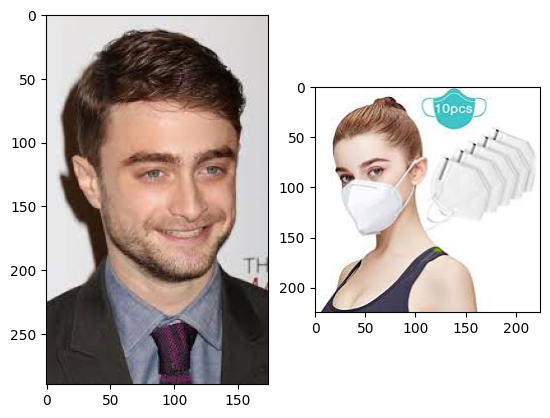

In [21]:
# Let's check how the images of both the classes look like
plt.subplot(1, 2, 1)
plt.imshow(mpimg.imread('face-mask-dataset/data/without_mask/' + without_mask_files[0]))
plt.subplot(1, 2, 2)
masked_image = Image.open('face-mask-dataset/data/with_mask/' + with_mask_files[0])
plt.imshow(masked_image)


In [22]:
# Number of with_mask and without_mask_images
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


**Dataset is pretty balanced**

In [23]:
# Creating labels for the two classes
# with_mask -> 1
# without_mask -> 0

with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [24]:
labels = with_mask_labels + without_mask_labels
print("First five labels :",labels[0:5])
print("Last five labels :",labels[-5:])

First five labels : [1, 1, 1, 1, 1]
Last five labels : [0, 0, 0, 0, 0]


# Image processing

1. Resize the images
2. Convert the images to numpy arrays

In [36]:

# Using Image.open you only get the image
img1 = Image.open('face-mask-dataset/data/with_mask/' + 'with_mask_973.jpg')
print("Image 1: ",img1)

# Using mpimg.imread you get the ndarray as well as an image
img2 = mpimg.imread('face-mask-dataset/data/without_mask/' + without_mask_files[0])
print("Image 2: ",img2)
# We got an image but if you use

Image 1:  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=95x120 at 0x7C74BDA21FD0>
Image 2:  [[[232 232 232]
  [232 232 232]
  [232 232 232]
  ...
  [212 211 209]
  [212 211 209]
  [212 211 209]]

 [[232 232 232]
  [232 232 232]
  [232 232 232]
  ...
  [212 211 209]
  [212 211 209]
  [212 211 209]]

 [[232 232 232]
  [232 232 232]
  [232 232 232]
  ...
  [212 211 209]
  [212 211 209]
  [212 211 209]]

 ...

 [[ 57  53  50]
  [ 54  53  49]
  [ 56  52  49]
  ...
  [ 42  41  37]
  [ 42  41  37]
  [ 42  41  37]]

 [[ 54  49  46]
  [ 53  49  46]
  [ 54  49  46]
  ...
  [ 40  39  35]
  [ 39  38  34]
  [ 41  40  36]]

 [[ 54  49  46]
  [ 54  49  46]
  [ 54  49  46]
  ...
  [ 40  39  35]
  [ 39  38  34]
  [ 41  40  36]]]


In [49]:
# Convert images to numpy arrays
with_mask_path = 'face-mask-dataset/data/with_mask/'
without_mask_path = 'face-mask-dataset/data/without_mask/'

data = []

# Process 'with_mask' images first
for filename in with_mask_files:
    img = cv2.imread(with_mask_path + filename)
    # Ensure image is not None (if file not found or corrupted)
    if img is not None:
        img = cv2.resize(img,(128,128))
        data.append(np.array(img))
    else:
        print(f"Warning: Could not read image {with_mask_path + filename}")

# Then process 'without_mask' images
for filename in without_mask_files:
    img = cv2.imread(without_mask_path + filename)
    # Ensure image is not None (if file not found or corrupted)
    if img is not None:
        img = cv2.resize(img,(128,128))
        data.append(np.array(img))
    else:
        print(f"Warning: Could not read image {without_mask_path + filename}")


In [50]:
print(type(data), len(data))

<class 'list'> 7553


In [54]:
# Converting image list and label list to numpy arrays
X = np.array(data)
y = np.array(labels)

print("Shape of X :",X.shape,"\nShape of y :",y.shape)

Shape of X : (7553, 128, 128, 3) 
Shape of y : (7553,)


**Train Test Split**

In [55]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
X_train.shape

(6042, 128, 128, 3)

In [58]:
# Let's normalise the dataset
X_train_scaled = X_train/255
X_test_scaled = X_test/255

**Building a Convolutional Neural Network**

In [64]:
import tensorflow as tf
from tensorflow import keras

In [63]:
num_of_classes = 2
model = keras.Sequential()

model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64,activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc']
)

In [66]:
# training the neural network
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split = 0.1,
    epochs=5
)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - acc: 0.7717 - loss: 0.5168 - val_acc: 0.8612 - val_loss: 0.3458
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8862 - loss: 0.2935 - val_acc: 0.8793 - val_loss: 0.3000
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8974 - loss: 0.2521 - val_acc: 0.8793 - val_loss: 0.3092
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9143 - loss: 0.2179 - val_acc: 0.8760 - val_loss: 0.3519
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9213 - loss: 0.1946 - val_acc: 0.9124 - val_loss: 0.2405


Model Evaluation

In [67]:
loss, accuracy = model.evaluate(X_test_scaled,y_test)
print("Test Accuracy :",accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9179 - loss: 0.2087
Test Accuracy : 0.9179351329803467


In [ ]:
# Let's do the visualization of the training and validation split

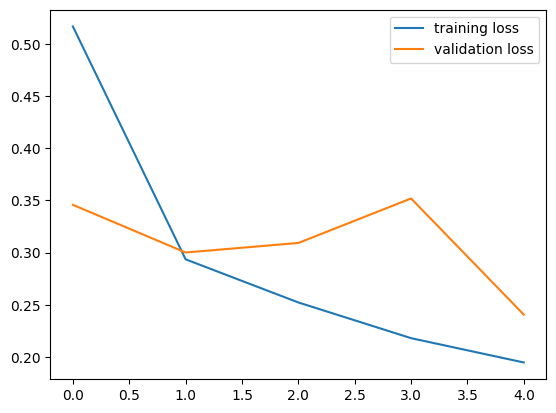

In [68]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

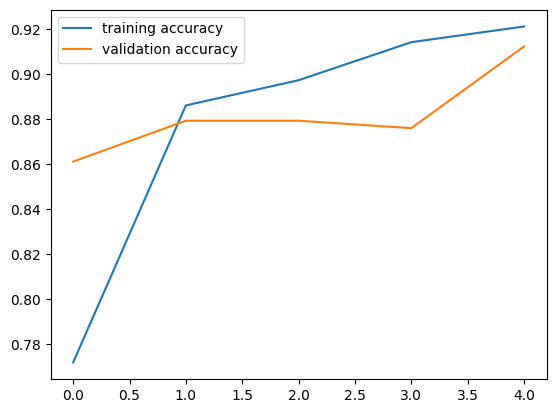

In [69]:
plt.plot(history.history['acc'], label='training accuracy')
plt.plot(history.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


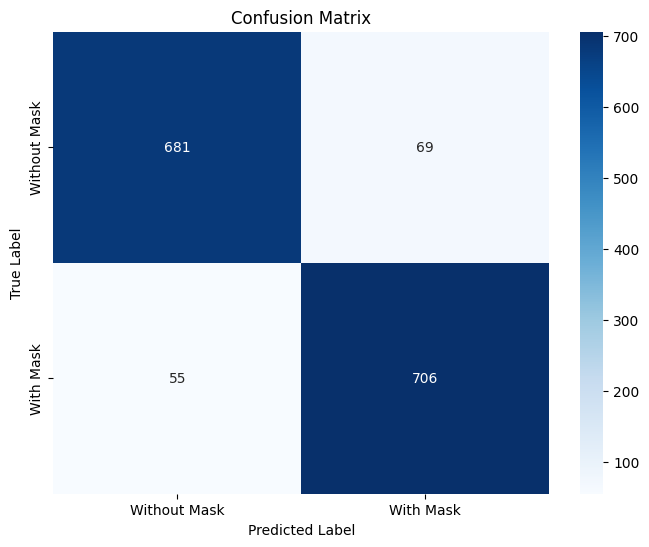

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Without Mask', 'With Mask'],
            yticklabels=['Without Mask', 'With Mask'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()